In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
SPLIT      = 'test'
NBINS      = 30
MINSAMPLES = 50
LFCURVES   = {'Ocean (LF = 0)':(0.0,'#539ED4'),'Coast (LF = 0.5)':(0.5,'gray6'),'Land (LF = 1)':(1.0,'#A0522D')}
REGISTRY   = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
              for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [4]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def calc_atm_exponent(rh,thetae,thetaestar):
    return eta*np.maximum(kappa*(rh-rh0),thetae-gamma*thetaestar-theta0)**3

def calc_sfc_correction(lf,shf,lhf):
    return lamshf*(lf0-lf)*(shf-shf0)+lamlhf*(lhf-lhf0)

def to_precip(exponent):
    return np.maximum(np.expm1(exponent),0.0)

def bin_2d(x,y,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges[0])-1,0,len(edges[0])-2)
    yi     = np.clip(np.digitize(y,edges[1])-1,0,len(edges[1])-2)
    shape  = (len(edges[0])-1,len(edges[1])-1)
    counts = np.zeros(shape)
    sums   = np.zeros(shape)
    np.add.at(counts,(xi,yi),1)
    np.add.at(sums,(xi,yi),z)
    return np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
c3,c4,c5 = (REGISTRY['sr_atm_eq']['constants'][name] for name in ['c3','c4','c5'])
c6,c7,c8 = (REGISTRY['sr_sfc_eq']['constants'][name] for name in ['c6','c7','c8'])

eta    = STATS['tp_std']*c3/STATS['thetae_std']**3
gamma  = c4*STATS['thetae_std']/STATS['thetaestar_std']
theta0 = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+c5*STATS['thetae_std']
kappa  = STATS['thetae_std']/STATS['rh_std']
rh0    = STATS['rh_mean']

lamshf = STATS['tp_std']*c6/STATS['shf_std']
lf0    = c7
shf0   = STATS['shf_mean']
lamlhf = STATS['tp_std']*c8/STATS['lhf_std']
lhf0   = STATS['lhf_mean']

constdf = pd.DataFrame([
    {'Constant':'$\\lambda_S$','Value':f'{lamshf:.3e}','Units':'m²/W'},
    {'Constant':'$\\mathrm{LF}_0$','Value':f'{lf0:.2f}','Units':'dimensionless'},
    {'Constant':'$\\mathrm{SHF}_0$','Value':f'{shf0:.2f}','Units':'W/m²'},
    {'Constant':'$\\lambda_L$','Value':f'{lamlhf:.3e}','Units':'m²/W'},
    {'Constant':'$\\mathrm{LHF}_0$','Value':f'{lhf0:.2f}','Units':'W/m²'}])
display(constdf.style.hide(axis='index'))

Constant,Value,Units
$\lambda_S$,1.250e-02,m²/W
$\mathrm{LF}_0$,0.74,dimensionless
$\mathrm{SHF}_0$,13.91,W/m²
$\lambda_L$,1.564e-03,m²/W
$\mathrm{LHF}_0$,124.39,W/m²


In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    dsig   = ds['dsig'].values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp,shf,lhf = (ds[name].transpose('time','lat','lon').values.ravel() for name in ['tp','shf','lhf'])
    lf     = xr.broadcast(ds['lf'],ds['tp'])[0].transpose('time','lat','lon').values.ravel()
with xr.open_dataset(os.path.join(PREDSDIR,f'sr_sfc_eq_{SPLIT}_predictions.nc')) as ds:
    savedtp = ds['tp'].squeeze().transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals  = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
atmexp     = calc_atm_exponent(integrals['rh'],integrals['thetae'],integrals['thetaestar'])
correction = calc_sfc_correction(lf,shf,lhf)
atmtp      = to_precip(atmexp)
sfctp      = to_precip(atmexp+correction)
finite     = np.isfinite(atmexp)&np.isfinite(correction)&np.isfinite(tp)
print(f'Max difference from saved SR-SFC predictions: {np.nanmax(np.abs(sfctp[finite]-savedtp[finite])):.2e} mm')

regions = {}
for region,regionmask in [('Ocean',finite&(lf<0.5)),('Land',finite&(lf>=0.5))]:
    edges = (np.linspace(*np.percentile(shf[regionmask],[1,99]),NBINS+1),
             np.linspace(*np.percentile(lhf[regionmask],[1,99]),NBINS+1))
    regions[region] = dict(
        centers=[0.5*(edge[:-1]+edge[1:]) for edge in edges],
        missed=bin_2d(shf[regionmask],lhf[regionmask],(tp-atmtp)[regionmask],edges),
        added=bin_2d(shf[regionmask],lhf[regionmask],(sfctp-atmtp)[regionmask],edges),
        density=np.log10(np.histogram2d(shf[regionmask],lhf[regionmask],bins=edges)[0].clip(1)))
difflim  = np.nanpercentile(np.abs([regions[region][key] for region in regions for key in ['missed','added']]),98)
denslim  = max(np.nanmax(regions[region]['density']) for region in regions)
shfrange = np.linspace(*np.percentile(shf[finite],[1,99]),200)
lhfrange = np.linspace(*np.percentile(lhf[finite],[1,99]),200)

Max difference from saved SR-SFC predictions: 8.94e-02 mm


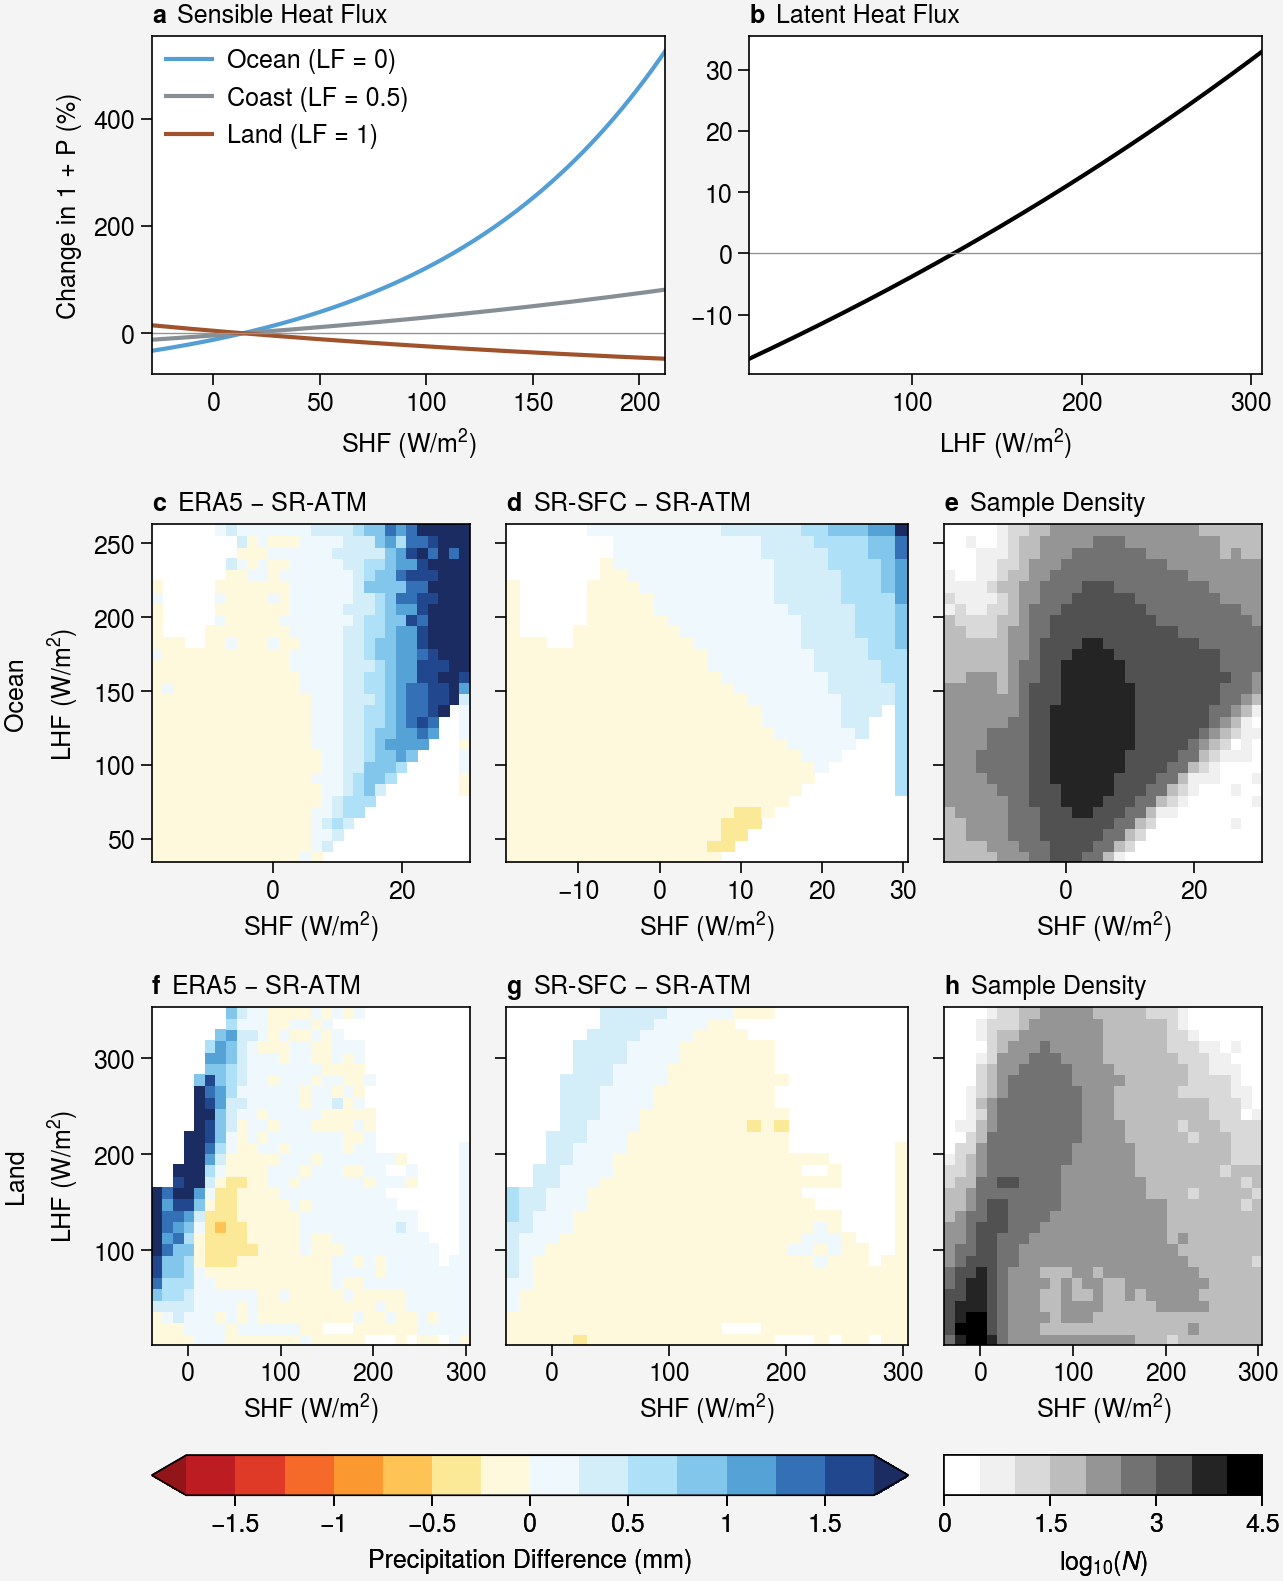

In [20]:
kwdiff = dict(cmap='ColdHot_r',vmin=-difflim,vmax=difflim,levels=16,extend='both')

fig,axs = pplt.subplots([[1,1,1,2,2,2],[3,3,4,4,5,5],[6,6,7,7,8,8]],figwidth=6.5,figheight=8,share=False)
for label,(lfvalue,color) in LFCURVES.items():
    axs[0].plot(shfrange,100*np.expm1(lamshf*(lf0-lfvalue)*(shfrange-shf0)),color=color,lw=1.5,label=label)
axs[1].plot(lhfrange,100*np.expm1(lamlhf*(lhfrange-lhf0)),color='k',lw=1.5)
for ax in axs[:2]:
    ax.axhline(0,color='gray',lw=0.5)
axs[0].format(title='Sensible Heat Flux',xlabel='SHF (W/m$^2$)',ylabel='Change in 1 + P (%)')
axs[1].format(title='Latent Heat Flux',xlabel='LHF (W/m$^2$)')
axs[0].legend(loc='ul',ncols=1,frame=False)
for row,region in zip([2,5],['Ocean','Land']):
    data = regions[region]
    mdiff = axs[row].pcolormesh(*data['centers'],data['missed'].T,**kwdiff)
    axs[row+1].pcolormesh(*data['centers'],data['added'].T,**kwdiff)
    mdens = axs[row+2].pcolormesh(*data['centers'],data['density'].T,cmap='Grays',vmin=0,vmax=denslim)
    axs[row].format(title='ERA5 $-$ SR-ATM',ylabel='LHF (W/m$^2$)')
    axs[row+1].format(title='SR-SFC $-$ SR-ATM',yticklabels=[])
    axs[row+2].format(title='Sample Density',yticklabels=[])
    axs[row:row+3].format(xlabel='SHF (W/m$^2$)',xlabelpad=2)
fig.format(abc=True,titleloc='l',grid=False,leftlabels=['','Ocean','Land'])
fig.colorbar(mdiff,loc='b',cols=(1,4),label='Precipitation Difference (mm)')
fig.colorbar(mdens,loc='b',cols=(5,6),label='log$_{10}$($\\mathit{N}$)')
pplt.show()
fig.save('../figs/fig_5.jpg')